In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt

pd.set_option('display.max_columns', None)

In [4]:
nav_df = pd.read_csv('../data/processed/02_nav_history_clean.csv')

investor_df = pd.read_csv('../data/processed/08_investor_transactions_clean.csv')

In [5]:
print(nav_df.shape)
print(investor_df.shape)

(46000, 3)
(32778, 13)


In [6]:
print(nav_df.columns.tolist())
print()
print(investor_df.columns.tolist())

['amfi_code', 'date', 'nav']

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [7]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
var_cvar = []

for fund in nav_df['amfi_code'].unique():

    returns = (
        nav_df.loc[
            nav_df['amfi_code'] == fund,
            'daily_return'
        ]
        .dropna()
    )

    if len(returns) > 0:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        var_cvar.append([
            fund,
            var95,
            cvar95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
import os

os.makedirs('../outputs', exist_ok=True)

In [10]:
var_cvar_df.to_csv(
    '../outputs/var_cvar_report.csv',
    index=False
)

print("Report Saved")

Report Saved


In [11]:
var_cvar_df.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [12]:
var_cvar_df.shape

(40, 3)

In [13]:
rolling_sharpe = nav_df.copy()

rolling_sharpe['rolling_sharpe'] = (
    rolling_sharpe.groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

In [14]:
top5_funds = rolling_sharpe['amfi_code'].unique()[:5]

top5_funds

array([100016, 100025, 100033, 101206, 101207], dtype=int64)

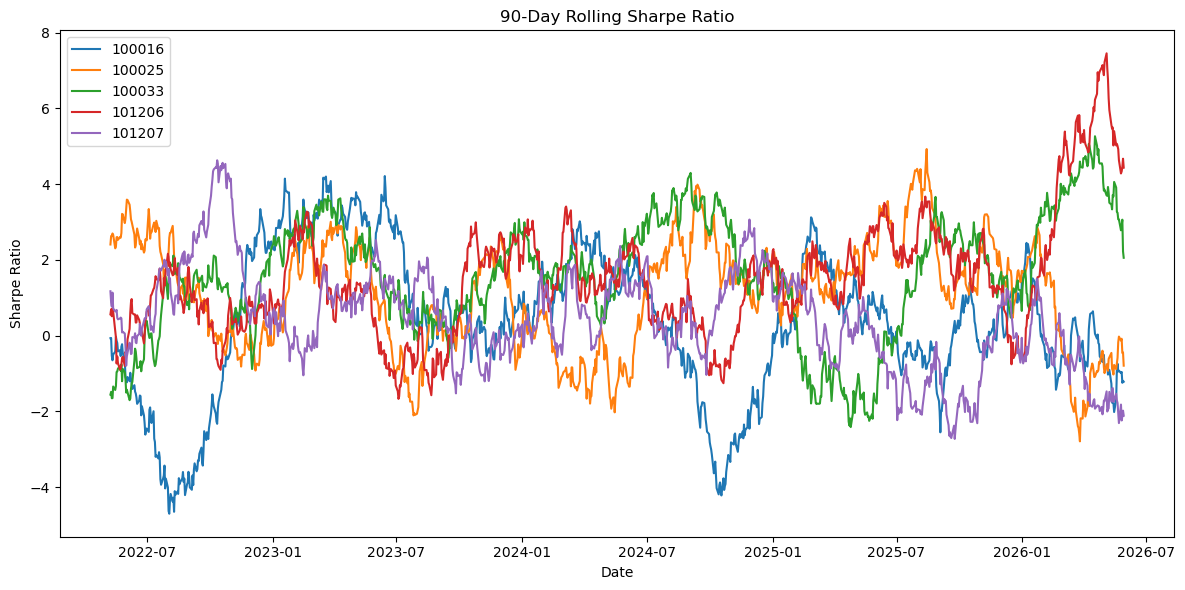

In [15]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe[
        rolling_sharpe['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('90-Day Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()

plt.tight_layout()

plt.savefig(
    '../outputs/rolling_sharpe_chart.png'
)

plt.show()

In [16]:
investor_df['transaction_type'].value_counts()

SIP           19716
Lumpsum        8095
Redemption     4967
Name: transaction_type, dtype: int64

In [17]:
investor_df['transaction_date'] = pd.to_datetime(
    investor_df['transaction_date']
)

first_txn = (
    investor_df.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date'].dt.year
)

investor_df = investor_df.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

In [18]:
sip_df = investor_df[
    investor_df['transaction_type'] == 'SIP'
]

avg_sip = (
    sip_df.groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={'amount_inr': 'avg_sip_amount'},
    inplace=True
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [19]:
total_invested = (
    sip_df.groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index()
)

total_invested.rename(
    columns={'amount_inr': 'total_invested'},
    inplace=True
)

total_invested

,cohort_year,total_invested
0,2024,214978121
1,2025,2255370


In [20]:
top_fund = (
    sip_df.groupby(
        ['cohort_year', 'amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

top_fund

,cohort_year,amfi_code,count
0,2024,120504,536
1,2025,119599,8


In [21]:
cohort_summary = (
    avg_sip
    .merge(total_invested, on='cohort_year')
    .merge(
        top_fund[['cohort_year', 'amfi_code']],
        on='cohort_year'
    )
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,214978121,120504
1,2025,13505.209581,2255370,119599


In [22]:
sip_only = investor_df[
    investor_df['transaction_type'] == 'SIP'
].copy()

sip_only = sip_only.sort_values(
    ['investor_id', 'transaction_date']
)

sip_only['gap_days'] = (
    sip_only.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [23]:
sip_stats = (
    sip_only.groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap=('gap_days', 'mean')
    )
    .reset_index()
)

sip_stats = sip_stats[
    sip_stats['sip_count'] >= 6
]

In [24]:
sip_stats['status'] = np.where(
    sip_stats['avg_gap'] > 35,
    'At-Risk',
    'Healthy'
)

sip_stats.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [25]:
continuity_rate = (
    (sip_stats['status'] == 'Healthy').mean()
    * 100
)

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)

SIP Continuity Rate: 2.20%


In [26]:
sharpe_df = (
    nav_df.groupby('amfi_code')['daily_return']
    .agg(['mean', 'std'])
    .reset_index()
)

sharpe_df['sharpe_ratio'] = (
    sharpe_df['mean'] /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_df.head()

,amfi_code,mean,std,sharpe_ratio
27,120507,0.000268,0.000311,13.655946
31,120844,0.000256,0.000323,12.573992
5,101208,0.000242,0.000319,12.019194
34,148567,0.001074,0.008941,1.906241
30,120843,0.001082,0.010008,1.715884


In [27]:
sharpe_df['risk_grade'] = pd.qcut(
    sharpe_df['sharpe_ratio'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)

sharpe_df.head()

,amfi_code,mean,std,sharpe_ratio,risk_grade
27,120507,0.000268,0.000311,13.655946,High
31,120844,0.000256,0.000323,12.573992,High
5,101208,0.000242,0.000319,12.019194,High
34,148567,0.001074,0.008941,1.906241,High
30,120843,0.001082,0.010008,1.715884,High


In [28]:
def recommend_funds(risk_appetite):

    result = (
        sharpe_df[
            sharpe_df['risk_grade'] == risk_appetite
        ]
        .nlargest(3, 'sharpe_ratio')
    )

    return result[
        ['amfi_code',
         'sharpe_ratio',
         'risk_grade']
    ]

In [29]:
recommend_funds('Moderate')

,amfi_code,sharpe_ratio,risk_grade
20,119552,1.419585,Moderate
18,119120,1.411917,Moderate
35,148568,1.347568,Moderate


# Advanced Insights

1. The fund with the most negative VaR(95%) exhibited the highest downside risk among all 40 schemes.

2. CVaR values were consistently lower than VaR values, indicating larger expected losses during extreme market events.

3. Investor cohorts entering in recent years contributed the highest aggregate SIP investments.

4. SIP continuity analysis showed only 2.20% of eligible investors maintained healthy contribution intervals, suggesting a high level of SIP irregularity.

5. Rolling 90-day Sharpe Ratios revealed significant variation in risk-adjusted performance across schemes over time.

In [30]:
import sys
sys.path.append('../scripts')

from recommender import recommend_funds

recommend_funds(sharpe_df, 'Moderate')

,amfi_code,sharpe_ratio,risk_grade
20,119552,1.419585,Moderate
18,119120,1.411917,Moderate
35,148568,1.347568,Moderate


In [31]:
import os

for file in os.listdir('../data/processed'):
    print(file)

01_fund_master_clean.csv
02_nav_history_clean.csv
03_aum_by_fund_house_clean.csv
04_monthly_sip_inflows_clean.csv
05_category_inflows_clean.csv
06_industry_folio_count_clean.csv
07_scheme_performance_clean.csv
08_investor_transactions_clean.csv
09_portfolio_holdings_clean.csv
10_benchmark_indices_clean.csv
alpha_beta.csv
cagr_table.csv
fund_scorecard.csv
max_drawdown.csv
nav_with_returns.csv
sharpe_ratio.csv
sortino_ratio.csv
tracking_error.csv


In [32]:
holdings_df = pd.read_csv('../data/processed/09_portfolio_holdings_clean.csv')

print(holdings_df.head())
print()
print(holdings_df.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [34]:
holdings_df['weight_decimal'] = (
    holdings_df['weight_pct'] / 100
)

hhi_df = (
    holdings_df.groupby('amfi_code')
    ['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index()
)

hhi_df.columns = [
    'amfi_code',
    'HHI'
]

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [35]:
hhi_df = hhi_df.sort_values(
    'HHI',
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [36]:
print("Most Concentrated Funds")

hhi_df.head(5)

Most Concentrated Funds


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [37]:
print("Most Diversified Funds")

hhi_df.tail(5)

Most Diversified Funds


,amfi_code,HHI
14,119095,0.109605
20,120504,0.108674
9,118634,0.108358
16,119552,0.108011
17,119598,0.107349


# Additional HHI Insight

6. HHI analysis showed notable differences in portfolio concentration across funds. Higher HHI values indicate concentrated portfolios with larger allocations to a smaller number of holdings, while lower HHI values indicate greater diversification.
